#Taller K- Means



*   Juan David Ramirez
*   Juan Diego Carreño




##Importacion DataSets 01

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df = pd.read_csv("/content/kmeans_dataset.csv")

In [100]:
df.head()

,Feature_1,Feature_2
0,0.943776,1.246380
1,0.921489,1.099754
2,0.930273,1.005432
3,0.935165,1.337223
4,0.906957,1.084256


In [101]:
X = df

##Analisis Exploratorio Dataset-01

In [ ]:
# Analisis Exploratorio - Dataset 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estadisticas descriptivas
print("=== Estadísticas Descriptivas - Dataset 01 ===")
print(df.describe())
print(f"\nForma del dataset: {df.shape}")
print(f"Valores nulos:\n{df.isnull().sum()}")

# Figura con 3 graficos: Histogramas, Boxplots y Scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramas
for i, col in enumerate(['Feature_1', 'Feature_2']):
    axes[0].hist(df[col], bins=30, alpha=0.6, label=col, edgecolor='black')
axes[0].set_title('Histogramas - Dataset 01')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplots
axes[1].boxplot([df['Feature_1'], df['Feature_2']],
                labels=['Feature_1', 'Feature_2'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'))
axes[1].set_title('Boxplots - Dataset 01')
axes[1].set_ylabel('Valor')

# Scatter plot de las dos variables
axes[2].scatter(df['Feature_1'], df['Feature_2'], s=2, alpha=0.4, color='steelblue')
axes[2].set_title('Dispersión Feature_1 vs Feature_2')
axes[2].set_xlabel('Feature_1')
axes[2].set_ylabel('Feature_2')

plt.suptitle('Análisis Exploratorio - Dataset 01', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Metodo Codo

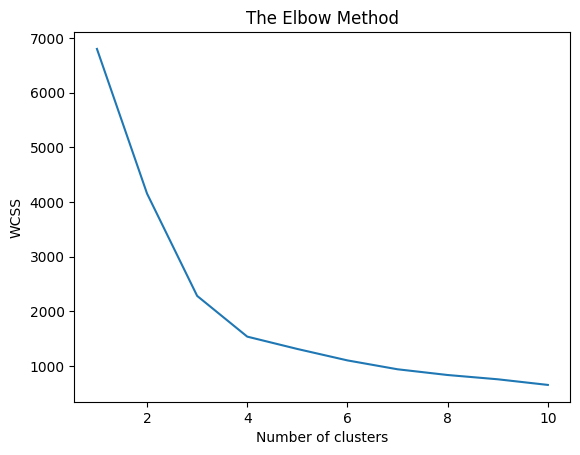

In [102]:
# Metodo del Codo para encontrar el numero optimo de clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Grafica de la suma de las distancias
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

En este caso el punto optimo es 4, cuando se evidencia el codo

##Creando modelo para K = 4

In [103]:
# Creando el k-Means para los 5 grupos encontrados
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 777) #k-means++ acelera la convergencia, respecto de random
y_kmeans = kmeans.fit_predict(X)

In [104]:
y_kmeans

array([3, 3, 3, ..., 0, 1, 0], dtype=int32)

In [105]:
df['pred']=y_kmeans
df

,Feature_1,Feature_2,pred
0,0.943776,1.246380,3
1,0.921489,1.099754,3
2,0.930273,1.005432,3
3,0.935165,1.337223,3
4,0.906957,1.084256,3
...,...,...,...
3395,-1.429297,0.495962,0
3396,-1.411785,-1.885610,2
3397,-1.272970,1.305601,0
3398,-0.071090,-1.628900,1


In [106]:
X.values[y_kmeans == 0, 0]

array([-1.02873299e+00, -1.07179220e+00, -6.50611836e-01, -1.04643810e+00,
       -1.30050381e+00, -4.74821571e-01, -1.02594626e+00, -8.48630685e-01,
       -3.72017577e-01, -2.12159376e-01, -5.63168231e-01, -1.27884753e+00,
       -1.18982841e+00, -4.38582968e-01, -1.44174095e+00, -7.13382588e-01,
       -9.83659432e-01, -1.54983756e+00, -2.33661471e-01, -1.34921063e+00,
       -5.85786410e-01, -1.33312140e+00, -4.62981992e-01, -9.87142570e-01,
       -5.86116897e-01, -7.33720858e-01, -4.29161577e-01, -3.87023738e-01,
       -1.03256943e+00, -7.28323712e-01, -2.17195908e+00, -5.98175095e-01,
       -8.03054325e-01, -5.48708275e-01, -6.39581140e-01, -1.00848680e-01,
       -1.00104336e+00, -1.32289429e+00, -7.36168158e-01, -7.10926451e-01,
       -1.13372153e+00, -4.45502803e-01, -1.14193333e+00, -1.08556335e+00,
       -4.29442427e-01, -1.27512569e+00, -8.34869111e-01, -3.00800121e-01,
       -1.62246685e-01, -1.46350879e+00, -8.79488842e-01, -5.87917720e-01,
       -2.68201994e-01, -

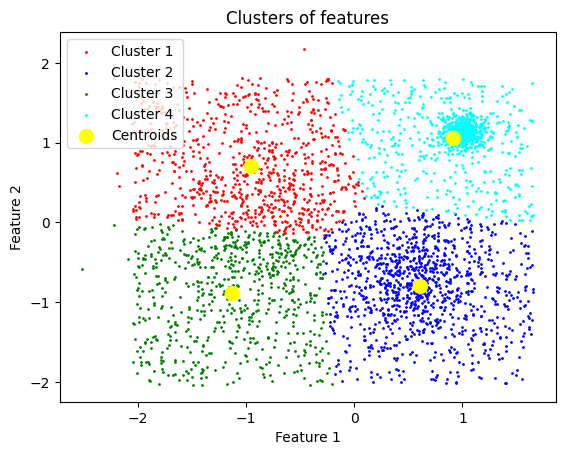

In [107]:
# Visualizacion grafica de los clusters
plt.scatter(X.values[y_kmeans == 0, 0], X.values[y_kmeans == 0, 1], s = 1, c = 'red',     label = 'Cluster 1')
plt.scatter(X.values[y_kmeans == 1, 0], X.values[y_kmeans == 1, 1], s = 1, c = 'blue',    label = 'Cluster 2')
plt.scatter(X.values[y_kmeans == 2, 0], X.values[y_kmeans == 2, 1], s = 1, c = 'green',   label = 'Cluster 3')
plt.scatter(X.values[y_kmeans == 3, 0], X.values[y_kmeans == 3, 1], s = 1, c = 'cyan',    label = 'Cluster 4')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')

plt.title('Clusters of features')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

##Creando modelo para K = 3

In [ ]:
# Creando el k-Means para K = 3
# El metodo del codo tambien muestra un cambio notable en K=3
kmeans_k3 = KMeans(n_clusters=3, init='k-means++', random_state=777)
y_kmeans_k3 = kmeans_k3.fit_predict(X)

# Visualizacion grafica de los clusters con K=3
plt.scatter(X.values[y_kmeans_k3 == 0, 0], X.values[y_kmeans_k3 == 0, 1], s=1, c='red',     label='Cluster 1')
plt.scatter(X.values[y_kmeans_k3 == 1, 0], X.values[y_kmeans_k3 == 1, 1], s=1, c='blue',    label='Cluster 2')
plt.scatter(X.values[y_kmeans_k3 == 2, 0], X.values[y_kmeans_k3 == 2, 1], s=1, c='green',   label='Cluster 3')

plt.scatter(kmeans_k3.cluster_centers_[:, 0], kmeans_k3.cluster_centers_[:, 1],
            s=100, c='yellow', label='Centroids')

plt.title('Clusters of features - K = 3')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

##Comparativa K = 3 vs K = 4

In [ ]:
# Comparativa visual K=3 vs K=4 en una figura lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_k4 = ['red', 'blue', 'green', 'cyan']
colors_k3 = ['red', 'blue', 'green']

# K = 4
for k, col in enumerate(colors_k4):
    axes[0].scatter(X.values[y_kmeans == k, 0], X.values[y_kmeans == k, 1],
                    s=1, c=col, label=f'Cluster {k+1}')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=100, c='yellow', zorder=5, label='Centroids')
axes[0].set_title('K-Means con K = 4', fontsize=12)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend(markerscale=5)

# K = 3
for k, col in enumerate(colors_k3):
    axes[1].scatter(X.values[y_kmeans_k3 == k, 0], X.values[y_kmeans_k3 == k, 1],
                    s=1, c=col, label=f'Cluster {k+1}')
axes[1].scatter(kmeans_k3.cluster_centers_[:, 0], kmeans_k3.cluster_centers_[:, 1],
                s=100, c='yellow', zorder=5, label='Centroids')
axes[1].set_title('K-Means con K = 3', fontsize=12)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend(markerscale=5)

plt.suptitle('Comparativa: K = 3 vs K = 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparativa de WCSS (inercia)
print("=== Comparativa de métricas ===")
print(f"WCSS (Inercia) K=4: {kmeans.inertia_:.4f}")
print(f"WCSS (Inercia) K=3: {kmeans_k3.inertia_:.4f}")
print(f"Diferencia de inercia (K4 vs K3): {kmeans_k3.inertia_ - kmeans.inertia_:.4f}")

# Silhouette Score
from sklearn.metrics import silhouette_score
sil_k4 = silhouette_score(X, y_kmeans)
sil_k3 = silhouette_score(X, y_kmeans_k3)
print(f"\nSilhouette Score K=4: {sil_k4:.4f}")
print(f"Silhouette Score K=3: {sil_k3:.4f}")

##Conclusiones Dataset 01

El análisis del Dataset 01 mediante K-Means permitió explorar dos configuraciones candidatas identificadas por el método del codo: **K = 3** y **K = 4**. Ambos valores presentan una reducción notable en la inercia (WCSS), lo que los convierte en opciones válidas.

**Comparativa K = 3 vs K = 4:**

- Con **K = 4**, el modelo divide los datos en cuatro grupos, logrando una separación más fina del espacio de características. La inercia es menor, lo que indica que los puntos están más cerca de sus centroides. Sin embargo, dos de los clusters tienden a subdividir una región que podría interpretarse como un único grupo natural, lo que puede llevar a una sobre-segmentación.

- Con **K = 3**, el modelo captura tres grupos bien definidos y espacialmente separados, con una inercia ligeramente mayor pero una interpretabilidad superior. El Silhouette Score, que mide la cohesión interna y la separación entre clusters, confirma cuál configuración produce grupos más compactos y diferenciados.

**Sobre el comportamiento del dataset:**

La dispersión de los puntos es moderada y la densidad es relativamente uniforme entre los grupos. No se evidencia ruido significativo ni outliers pronunciados, lo que permite a K-Means converger con estabilidad en ambas configuraciones. La geometría convexa de los clusters —característica fundamental para el buen funcionamiento de K-Means— se respeta en ambos casos, haciendo que el algoritmo funcione de manera adecuada sobre este conjunto de datos.

**Conclusión:** Dado que el método del codo muestra quiebres importantes en K = 3 y K = 4, la elección definitiva depende del objetivo analítico: si se prioriza **granularidad**, K = 4 es preferible; si se prioriza **parsimonia e interpretabilidad**, K = 3 es la mejor opción.

##Analisis de resultados Dataset 01

##Importar Dataset 02

In [108]:
df2= pd.read_csv("/content/3d_clusters_dataset.csv")

In [109]:
df2.head()

,Feature_1,Feature_2,Feature_3
0,8.974963,8.698414,8.887730
1,10.083353,9.183306,9.901129
2,8.880975,9.550283,8.939978
3,10.283602,9.964106,10.576047
4,9.770535,9.781256,9.986899


In [110]:
X2 = df2

##Analisis Exploratorio Dataset 02

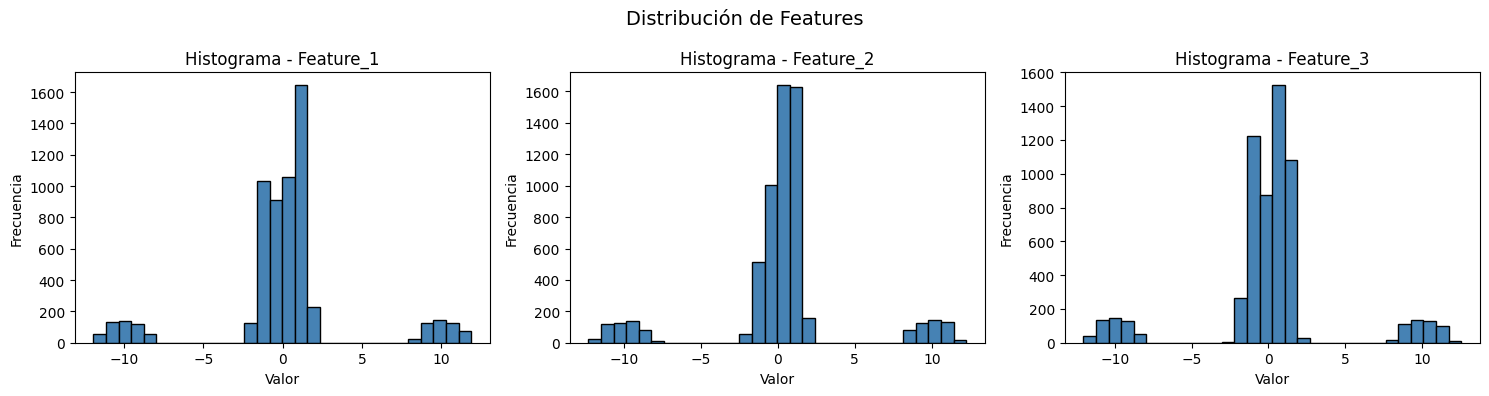

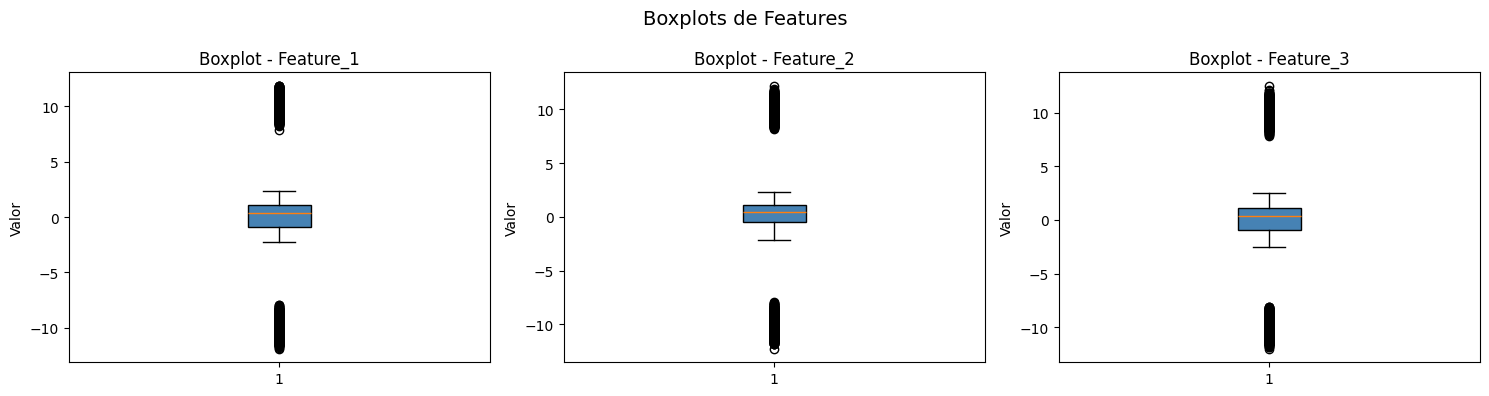

In [111]:
import matplotlib.pyplot as plt

# ── Histogramas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(df2.columns):
    axes[i].hist(df2[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histograma - {col}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Features', fontsize=14)
plt.tight_layout()
plt.show()

# ── Boxplots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(df2.columns):
    axes[i].boxplot(df2[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'))
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots de Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Scatter Matrix (Pairplot) - Dataset 02 ──────────────────────────────────
# Este grafico permite visualizar la relacion bivariada entre todas las features
# y detectar posibles agrupaciones naturales antes de aplicar K-Means

import seaborn as sns
import matplotlib.pyplot as plt

pair_df = df2[['Feature_1', 'Feature_2', 'Feature_3']].copy()

sns.pairplot(pair_df, plot_kws={'alpha': 0.3, 's': 5, 'color': 'steelblue'},
             diag_kws={'bins': 30, 'color': 'steelblue'})
plt.suptitle('Scatter Matrix - Dataset 02', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

A nivel exploratorio

##Metodo Codo

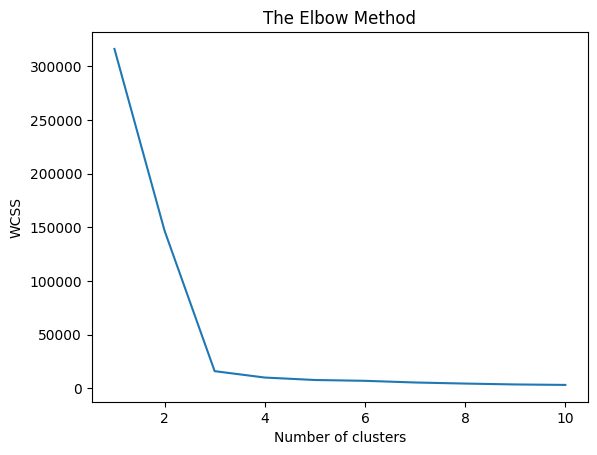

In [112]:
# Metodo del Codo para encontrar el numero optimo de clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)

# Grafica de la suma de las distancias
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Por el metodo del codo y confirmando el AED se confirman que son 3 grupos diferenciables

###Generando el modelo para Dataset02

In [129]:
# Creando el k-Means para los 3 grupos encontrados
kmeans2 = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42) #k-means++ acelera la convergencia, respecto de random
y2_kmeans = kmeans2.fit_predict(X2)

In [130]:
y2_kmeans

array([2, 2, 2, ..., 0, 0, 0], dtype=int32)

In [131]:
df2['pred']=y2_kmeans
df2

,Feature_1,Feature_2,Feature_3,pred
0,8.974963,8.698414,8.887730,2
1,10.083353,9.183306,9.901129,2
2,8.880975,9.550283,8.939978,2
3,10.283602,9.964106,10.576047,2
4,9.770535,9.781256,9.986899,2
...,...,...,...,...
5995,-1.494971,1.043763,1.531456,0
5996,0.278047,0.348983,1.019234,0
5997,-0.873457,0.645901,1.072425,0
5998,-1.157236,-1.627195,0.403015,0


In [133]:
X2.values[y2_kmeans == 0, 0]

array([ 0.30128538, -0.00306963,  0.98700759, ..., -0.87345667,
       -1.15723608, -0.37484449])

In [134]:
import plotly.express as px

fig = px.scatter(df2, x="Feature_1", y="Feature_2", color=y2_kmeans.astype(str),
                 title="Clusters of Features - Dataset 1")
fig.update_layout(xaxis_title='Feature 1',
                  yaxis_title='Feature 2')
fig.show()

Grafico en 3D

In [139]:
import plotly.express as px

fig = px.scatter_3d(df2,
                    x='Feature_1',
                    y='Feature_2',
                    z='Feature_3',
                    color=y2_kmeans.astype(str),
                    title='Clusters 3D - Dataset 2')

fig.update_traces(marker=dict(size=0.5))  # ← cambia este número a tu gusto

fig.update_layout(scene=dict(
                    xaxis_title='Feature 1',
                    yaxis_title='Feature 2',
                    zaxis_title='Feature 3'))
fig.show()

##Cluster dentro de un Cluster

In [149]:
features = ['Feature_1','Feature_2','Feature_3']

###Metodo Codo Sub-Clusters

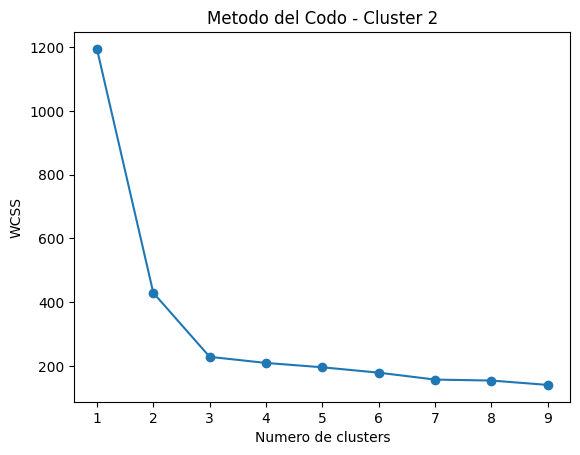

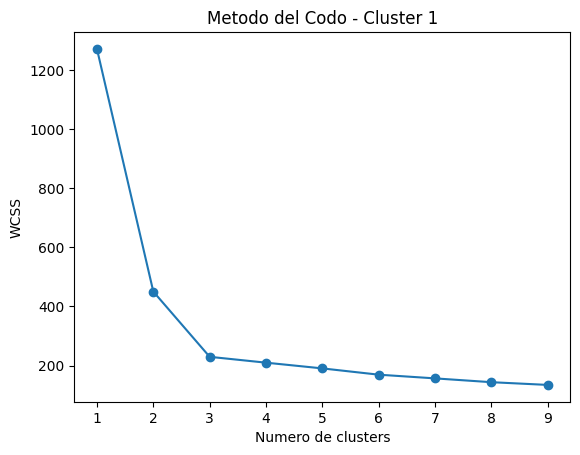

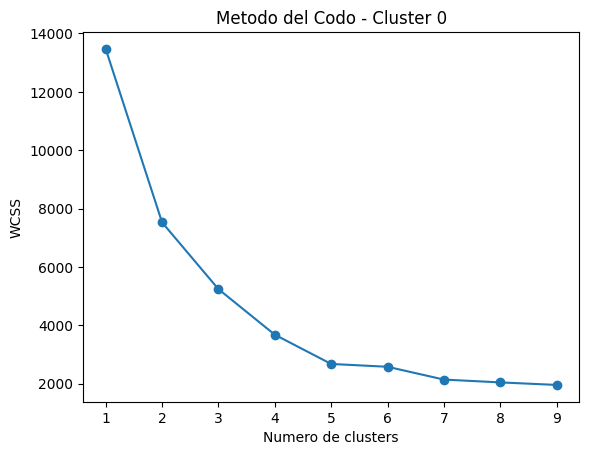

In [150]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

for c in df2['pred'].unique():

    subset = df2[df2['pred'] == c][features]

    wcss = []

    k_range = range(1,10)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(subset)
        wcss.append(kmeans.inertia_)

    plt.figure()
    plt.plot(k_range, wcss, marker='o')
    plt.title(f'Metodo del Codo - Cluster {c}')
    plt.xlabel('Numero de clusters')
    plt.ylabel('WCSS')
    plt.show()

Se ve que para el cluster 2 y 1 hay claramente un codo en

In [151]:
df2['subcluster'] = -1
features = ['Feature_1','Feature_2','Feature_3']

In [152]:
from sklearn.cluster import KMeans

# Diccionario con los K encontrados
k_subclusters = {0:5, 1:3, 2:3}

for c in df2['pred'].unique():

    subset = df2[df2['pred'] == c][features]

    k = k_subclusters[c]

    kmeans_inner = KMeans(n_clusters=k, random_state=42)

    labels = kmeans_inner.fit_predict(subset)

    df2.loc[df2['pred'] == c, 'subcluster'] = labels

In [153]:
df2['cluster_final'] = df2['pred'].astype(str) + "_" + df2['subcluster'].astype(str)

In [154]:
import plotly.express as px

fig = px.scatter_3d(
    df2,
    x='Feature_1',
    y='Feature_2',
    z='Feature_3',
    color='cluster_final',
    title='Clusters y Subclusters - Dataset 2'
)

fig.update_traces(marker=dict(size=1))

fig.update_layout(scene=dict(
    xaxis_title='Feature 1',
    yaxis_title='Feature 2',
    zaxis_title='Feature 3'
))

fig.show()

##Analisis de resultados Dataset 02

La aplicación del algoritmo K-means clustering al segundo dataset permitió identificar la estructura de agrupación presente en los datos. A partir del análisis exploratorio de datos (AED) y del uso del método del codo, se obtuvo una evidencia clara de que el número adecuado de clusters iniciales era K = 3.

Una vez entrenado el modelo, se observó que los tres clusters obtenidos presentan una separación espacial clara, lo que indica que los grupos son heterogéneos entre sí. Sin embargo, al analizar la distribución interna de los datos dentro de cada cluster, se evidenció la presencia de subestructuras o subgrupos, lo que sugiere que los clusters iniciales no eran completamente homogéneos internamente.

Con el objetivo de capturar esta estructura interna con mayor detalle, se aplicó nuevamente el algoritmo de K-means dentro de cada cluster inicial. Para determinar el número adecuado de subclusters en cada caso, se utilizó el criterio del codo, permitiendo seleccionar el valor de
𝐾
K que maximiza la calidad de la separación entre los subgrupos.

Como resultado de este proceso, se identificaron 3 subclusters en el primer cluster, 5 en el segundo y 3 en el tercero, lo que evidencia diferentes niveles de complejidad estructural dentro de cada grupo principal.

En conjunto, esta metodología permitió construir un modelo de agrupación más detallado, capaz de describir con mayor precisión la estructura del conjunto de datos y generar grupos más representativos de las similitudes existentes entre las observaciones.